EXR raw shape: (1, 128, 128, 3) processed: (128, 128, 3) dtype: float32


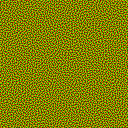

In [28]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
from PIL import Image

def load_exr_as_float32(path: str) -> np.ndarray:
    """Load an EXR file and return a float32 numpy array with shape (H, W, C)."""
    # Read EXR as float32 and fix common shape layouts
    exr = iio.imread(path)  # float32 array
    arr = np.array(exr, dtype=np.float32)

    # Drop leading frame dimension if present (e.g., (1, H, W, C))
    if arr.ndim == 4 and arr.shape[0] == 1:
        arr = arr[0]

    # Move channels-first (C, H, W) to channels-last
    if arr.ndim == 3 and arr.shape[0] in (3, 4) and arr.shape[-1] not in (3, 4):
        arr = np.moveaxis(arr, 0, -1)

    # If grayscale, replicate to RGB for display
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)

    # Trim to RGB if alpha exists
    arr = arr[..., :3]

    print("EXR raw shape:", exr.shape, "processed:", arr.shape, "dtype:", arr.dtype)

    # Normalize for visualization (global min/max)
    low = float(np.min(arr))
    high = float(np.max(arr))
    if high == low:
        high = low + 1.0
    vis = np.clip((arr - low) / (high - low), 0.0, 1.0)

    noisemap = Image.fromarray((vis * 255).astype(np.uint8))
    return noisemap

path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples1000000_od400_lidx0of15_0.exr"

noisemap_a = load_exr_as_float32(path)
display(noisemap_a)

# Optimal Transport (OMT)

## Test case

In [29]:
import numpy as np
import ot
from pathlib import Path
from typing import Optional, Tuple
from PIL import Image

pathA = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples1000000_od400_lidx0of15.png")
pathB = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples1000000_od400_lidx2of15.png")

desired_resolution: Optional[Tuple[int, int]] = (70,70)  # (height, width)

def load_gray(path: Path, resolution: Optional[Tuple[int, int]] = None, resample: int = Image.BILINEAR) -> np.ndarray:
    with Image.open(path) as img:
        if resolution is not None:
            target_height, target_width = resolution
            if img.size != (target_width, target_height):
                img = img.resize((target_width, target_height), resample=resample)
        data = np.asarray(img, dtype=np.float64)
    return data

density_a = load_gray(pathA, resolution=desired_resolution)
density_b = load_gray(pathB, resolution=desired_resolution)

total_a = density_a.sum()
total_b = density_b.sum()

source_mass = (density_a / total_a).ravel() # flatten to 1D
target_mass = (density_b / total_b).ravel()

# construct unit square coordinates ("pixel positions")
height, width = density_a.shape
unit_y = np.linspace(-1.0, 1.0, height, dtype=np.float64)
unit_x = np.linspace(-1.0, 1.0, width, dtype=np.float64)
unit_mesh_y, unit_mesh_x = np.meshgrid(unit_y, unit_x, indexing="ij")
source_coords = np.stack((unit_mesh_y, unit_mesh_x), axis=-1)
unit_positions = source_coords.reshape(-1, 2)

solution = ot.solve_sample(
    unit_positions,
    unit_positions,
    source_mass,
    target_mass,
    unbalanced=10#, # allow some mass variation penalized in cost function according to unbalanced parameter
    #reg=1e-1,   # allows mass to spread out more, smoothing the transport plan -> sinkhorn algorithm possible for faster computation
 )
plan = solution.plan # how much mass moves from pixel i to pixel j

# average expected target positions to one specific location
plan_row_mass = plan.sum(axis=1)
expected_targets = unit_positions.copy()  # keep identity where the plan has no mass
mass_mask = plan_row_mass > 1e-9
np.divide(plan @ unit_positions, plan_row_mass[:, None], out=expected_targets, where=mass_mask[:, None])

# calculate distortion vectors
omt_vectors = (expected_targets - unit_positions).reshape(height, width, 2)

source_coords_unit = source_coords
divergence = np.linalg.norm(plan_row_mass - source_mass)
print("omt_vectors ready with shape", omt_vectors.shape)
print("plan row-mass divergence", divergence)
print("pixels keeping identity due to low mass", (~mass_mask).sum())

C:\Users\ckobalt\AppData\Local\anaconda3\Lib\site-packages\ot\backend.py:1424: RuntimeWarning: invalid value encountered in divide
  value = np.sum(p * np.log(p / q + eps))


omt_vectors ready with shape (70, 70, 2)
plan row-mass divergence 9.538930947846082e-05
pixels keeping identity due to low mass 957


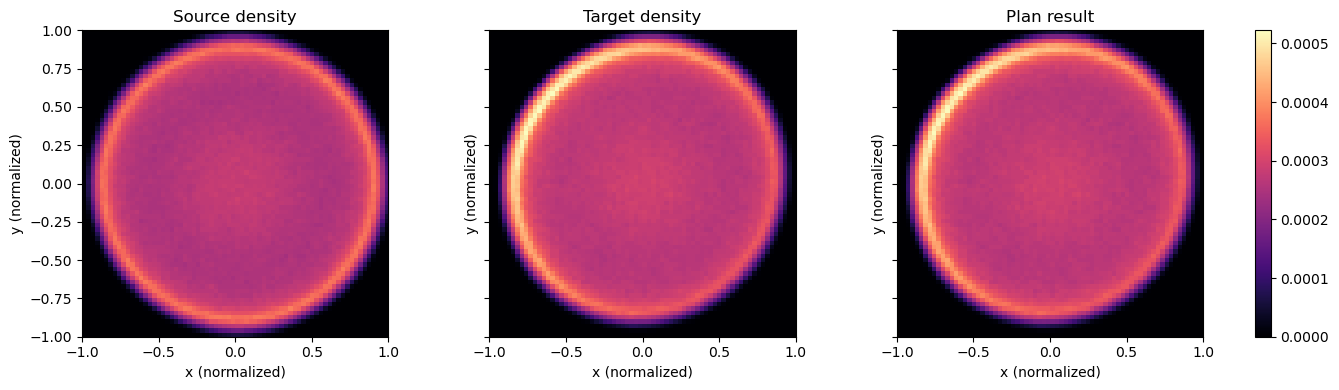

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

source_grid = source_mass.reshape(height, width)
target_grid = target_mass.reshape(height, width)
transported_grid = plan.sum(axis=0).reshape(height, width)
transported_grid = transported_grid / transported_grid.sum()

grids = [source_grid, target_grid, transported_grid]
norm = colors.Normalize(
    vmin=min(grid.min() for grid in grids),
    vmax=max(grid.max() for grid in grids),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
titles = ["Source density", "Target density", "Plan result"]

for ax, title, data in zip(axes, titles, grids):
    im = ax.imshow(
        data,
        origin="lower",
        extent=[-1.0, 1.0, -1.0, 1.0],
        cmap="magma",
        norm=norm,
    )
    ax.set_title(title)
    ax.set_xlabel("x (normalized)")
    ax.set_ylabel("y (normalized)")

plt.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
plt.show()

C:\Users\ckobalt\AppData\Local\Temp\1\ipykernel_52384\2516015797.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


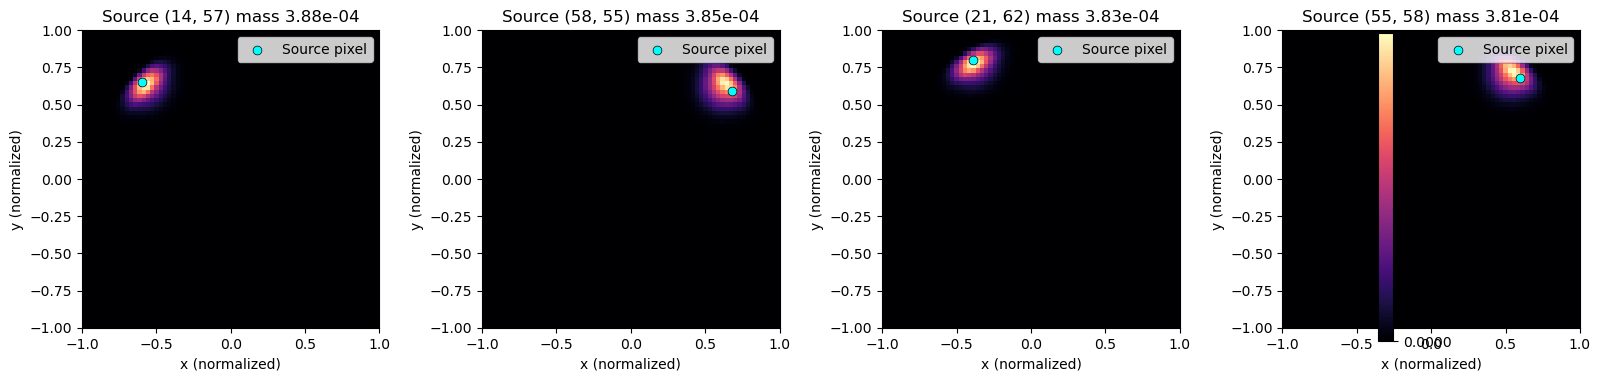

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# surface the spread of a few representative source pixels
top_indices = np.argsort(plan_row_mass)[::-1]
pixels_to_show = []
for flat_idx in top_indices:
    if plan_row_mass[flat_idx] <= 1e-9:
        continue
    y_idx = flat_idx // width
    x_idx = flat_idx % width
    pixels_to_show.append((y_idx, x_idx))
    if len(pixels_to_show) == 4:
        break

if not pixels_to_show:
    raise RuntimeError("No source pixels with sufficient transport mass found.")

fig, axes = plt.subplots(1, len(pixels_to_show), figsize=(4 * len(pixels_to_show), 4))
if len(pixels_to_show) == 1:
    axes = [axes]

for ax, (y_idx, x_idx) in zip(axes, pixels_to_show):
    row_id = y_idx * width + x_idx
    spread = plan[row_id].reshape(height, width)
    if spread.sum() > 0.0:
        spread_display = spread / spread.sum()
    else:
        spread_display = spread

    im = ax.imshow(
        spread_display,
        origin="lower",
        extent=[-1.0, 1.0, -1.0, 1.0],
        cmap="magma",
    )
    ax.scatter(
        source_coords_unit[y_idx, x_idx, 1],
        source_coords_unit[y_idx, x_idx, 0],
        color="cyan",
        s=40,
        edgecolor="black",
        linewidth=0.5,
        label="Source pixel",
    )
    ax.set_title(f"Source ({x_idx}, {y_idx}) mass {plan_row_mass[row_id]:.2e}")
    ax.set_xlabel("x (normalized)")
    ax.set_ylabel("y (normalized)")
    ax.legend(loc="upper right")

cbar = fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label("Transported mass fraction")
plt.tight_layout()
plt.show()

In [32]:
from pathlib import Path
from PIL import Image

# encode normalized distortion vectors into an RGB image (RG = x/y channels)
distortion_map = source_coords_unit + omt_vectors  # reconstruct destination grid before encoding
distortion_xy = np.stack((distortion_map[..., 1], distortion_map[..., 0]), axis=-1)
uint8_data = ((distortion_xy + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
distortion_rgb = np.zeros((height, width, 3), dtype=np.uint8)
distortion_rgb[..., :2] = uint8_data

output_path = pathA.parent / "distortion_vectors.png"
Image.fromarray(distortion_rgb, mode="RGB").save(output_path)
print(f"Saved distortion vectors to {output_path}")

Saved distortion vectors to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\weights\distortion_vectors.png


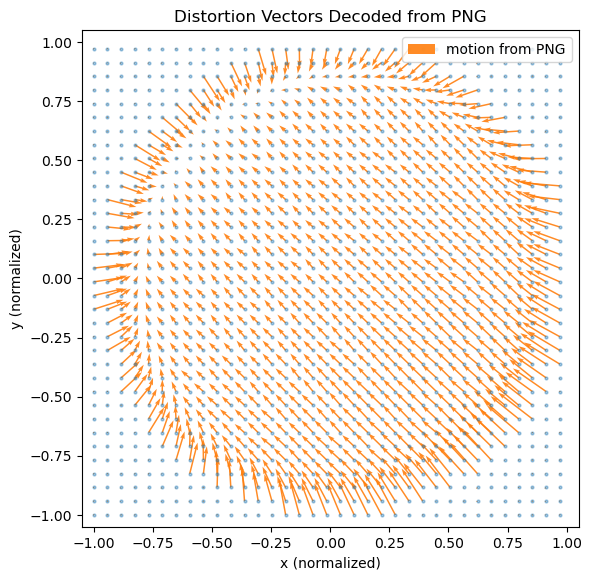

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

height, width = density_a.shape
step = max(1, int(max(height, width) / 30))

# load saved vectors
encoded = np.asarray(Image.open(pathA.parent / "distortion_vectors.png"), dtype=np.float32)
decoded = (encoded[..., :2] / 127.5) - 1.0
dest_x = decoded[..., 0]
dest_y = decoded[..., 1]

source_x = source_coords_unit[..., 1]
source_y = source_coords_unit[..., 0]

dx = dest_x - source_x
dy = dest_y - source_y

plt.figure(figsize=(6, 6))
plt.quiver(
    source_x[::step, ::step],
    source_y[::step, ::step],
    dx[::step, ::step],
    dy[::step, ::step],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.003,
    color="tab:orange",
    alpha=0.9,
    pivot="tail",
    label="motion from PNG",
)
plt.scatter(source_x[::step, ::step], source_y[::step, ::step], s=4, color="tab:blue", alpha=0.4)
plt.title("Distortion Vectors Decoded from PNG")
plt.xlabel("x (normalized)")
plt.ylabel("y (normalized)")
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

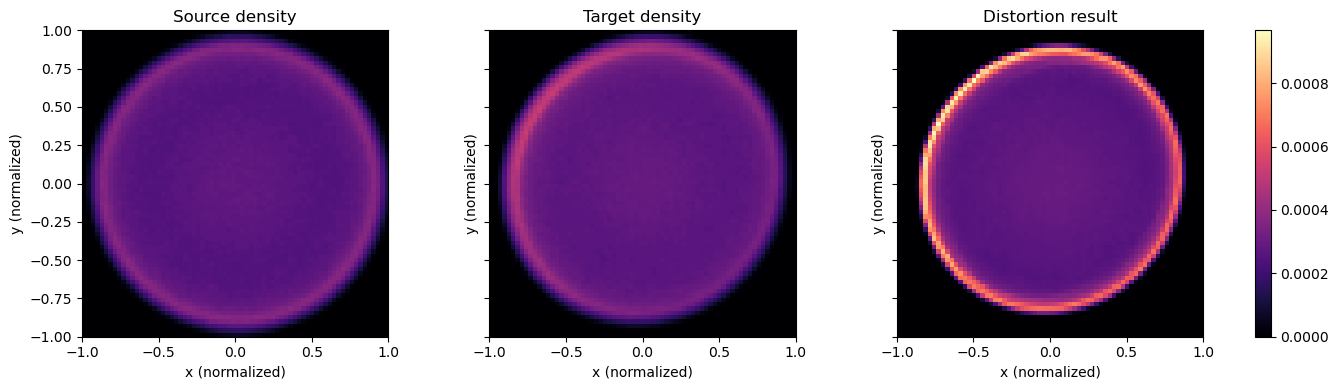

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

source_grid = source_mass.reshape(height, width)
target_grid = target_mass.reshape(height, width)
distorted = source_coords_unit + omt_vectors
dest_y_norm = distorted[..., 0]
dest_x_norm = distorted[..., 1]

# map normalized coordinates in [-1, 1] to pixel indices and scatter mass bilinearly
dest_x_px = np.clip((dest_x_norm + 1.0) * 0.5 * (width - 1), 0.0, width - 1.0)
dest_y_px = np.clip((dest_y_norm + 1.0) * 0.5 * (height - 1), 0.0, height - 1.0)

x0 = np.floor(dest_x_px).astype(np.int64)
y0 = np.floor(dest_y_px).astype(np.int64)
x1 = np.clip(x0 + 1, 0, width - 1)
y1 = np.clip(y0 + 1, 0, height - 1)
wx = dest_x_px - x0
wy = dest_y_px - y0
w00 = (1.0 - wx) * (1.0 - wy)
w10 = wx * (1.0 - wy)
w01 = (1.0 - wx) * wy
w11 = wx * wy

expected_density = np.zeros((height, width), dtype=np.float64)
mass_grid = source_grid
np.add.at(expected_density, (y0, x0), mass_grid * w00)
np.add.at(expected_density, (y0, x1), mass_grid * w10)
np.add.at(expected_density, (y1, x0), mass_grid * w01)
np.add.at(expected_density, (y1, x1), mass_grid * w11)

if expected_density.sum() > 0.0:
    expected_density /= expected_density.sum()

grids = [source_grid, target_grid, expected_density]
norm = colors.Normalize(
    vmin=min(grid.min() for grid in grids),
    vmax=max(grid.max() for grid in grids),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
titles = ["Source density", "Target density", "Distortion result"]

for ax, title, data in zip(axes, titles, grids):
    im = ax.imshow(
        data,
        origin="lower",
        extent=[-1.0, 1.0, -1.0, 1.0],
        cmap="magma",
        norm=norm,
    )
    ax.set_title(title)
    ax.set_xlabel("x (normalized)")
    ax.set_ylabel("y (normalized)")

plt.tight_layout()
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
plt.show()

In [35]:

pathAB = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/bokeh_fl45.0_as6_samples1000000_od400_lidx1of15.png")

density_ab = load_gray(pathAB, resolution=desired_resolution)

total_ab = density_ab.sum()
inbetween_mass_ab = (density_ab / total_ab).ravel()
inbetween_grid_ab = inbetween_mass_ab.reshape(height, width)


--- Refinement: omt ---
Using device: cpu
iter 0001 total 0.000110 (primary 0.000056, mid 0.000030, smooth 0.000454, mag 0.004390)
iter 0500 total 0.000027 (primary 0.000011, mid 0.000011, smooth 0.000073, mag 0.003267)
iter 1000 total 0.000014 (primary 0.000003, mid 0.000009, smooth 0.000020, mag 0.003211)
iter 1500 total 0.000013 (primary 0.000002, mid 0.000009, smooth 0.000015, mag 0.003235)
iter 2000 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000015, mag 0.003257)
iter 2500 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000015, mag 0.003288)
iter 3000 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000015, mag 0.003319)
iter 3500 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000015, mag 0.003348)
iter 4000 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000015, mag 0.003372)
iter 4500 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000016, mag 0.003393)
iter 5000 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.

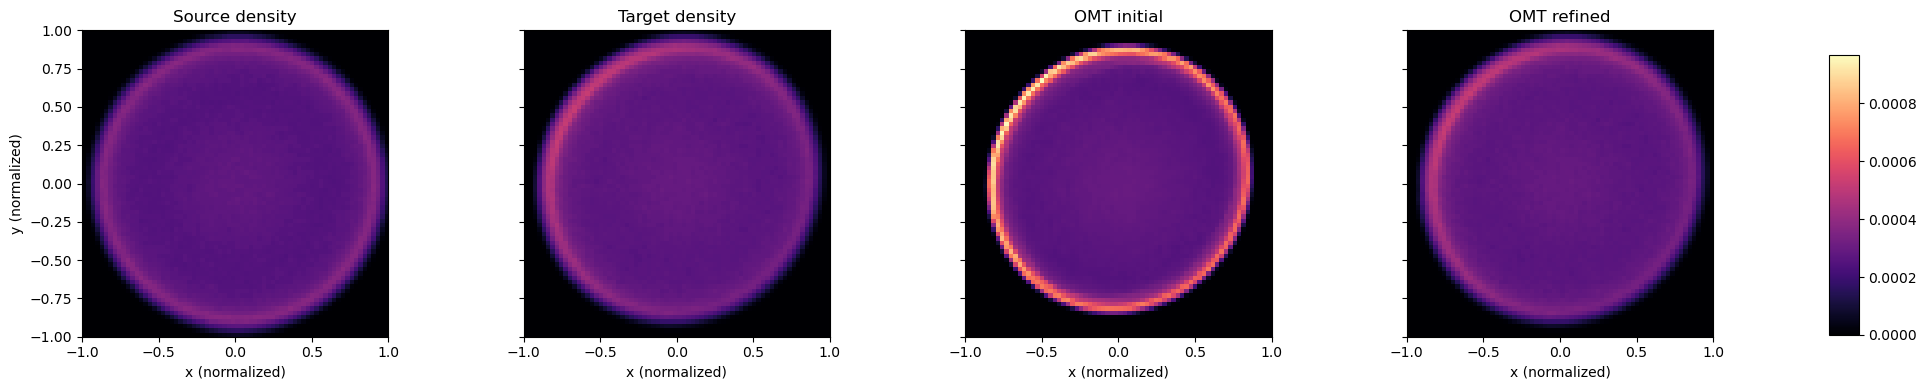

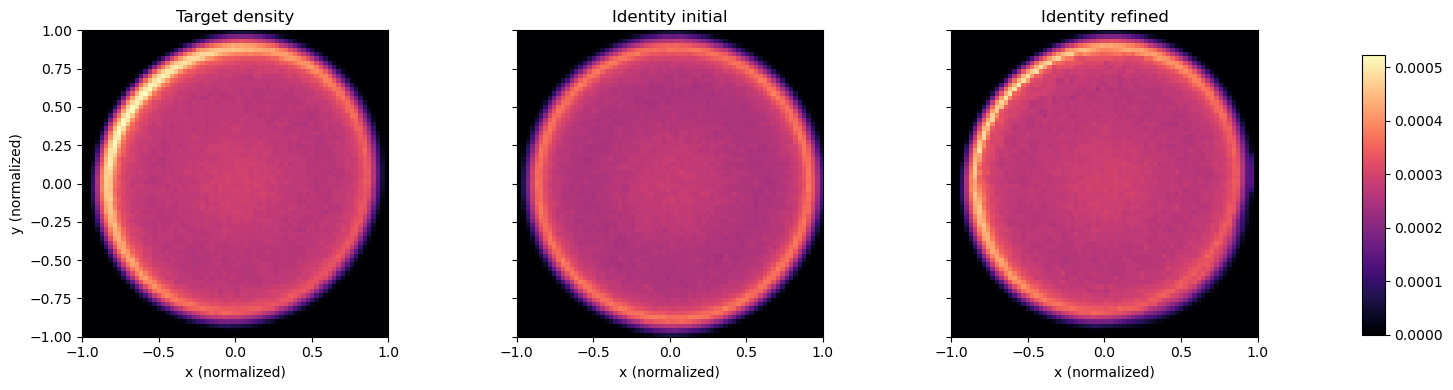

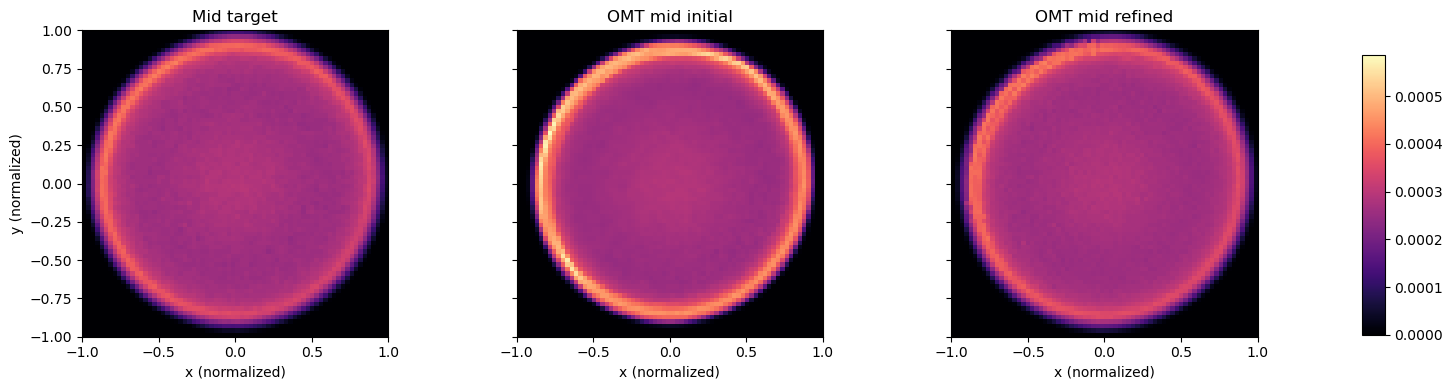

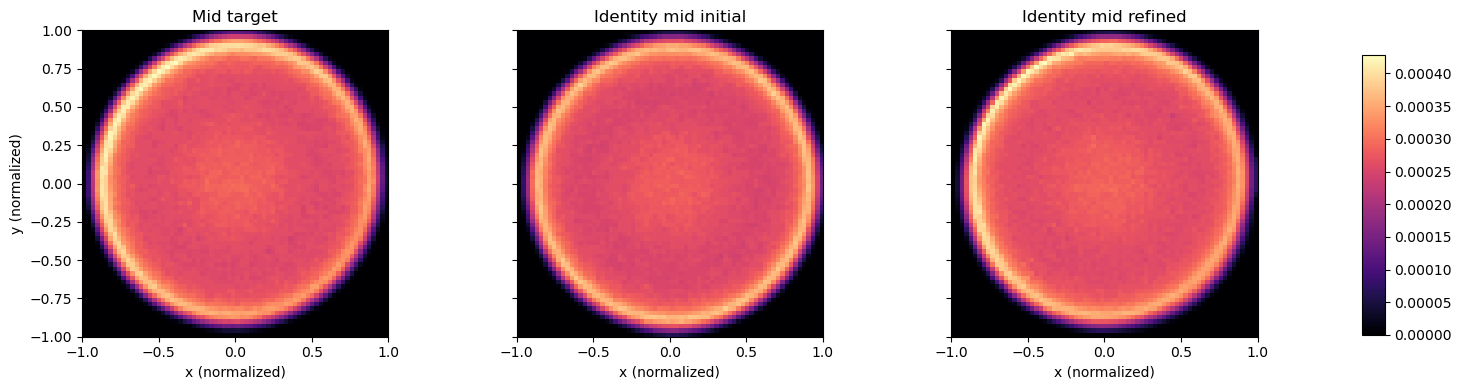

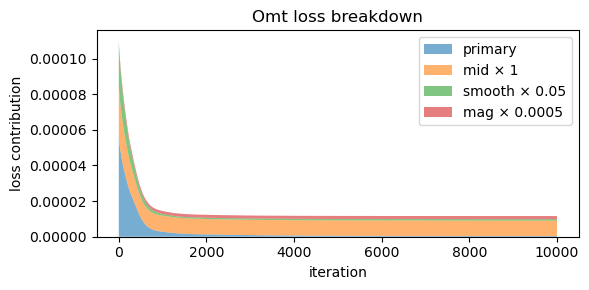

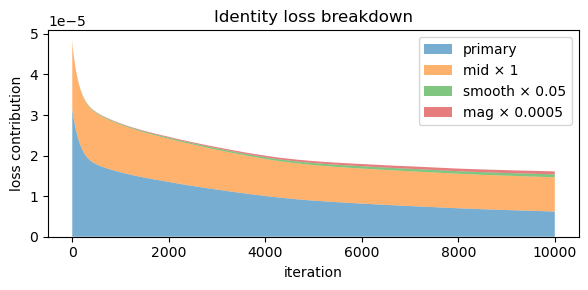

In [36]:
import torch
from matplotlib import colors

def refine_density_with_adam(
    source_coords_np: np.ndarray,
    source_density_np: np.ndarray,
    target_density_np: np.ndarray,
    *,
    init_field_np: np.ndarray | None = None,
    mid_density_np: np.ndarray | None = None,
    mid_weight: float = 1.0,
    smoothness_weight: float = 0.0,
    magnitude_weight: float = 0.0,
    lr: float = 1e-3,
    max_iters: int = 10_000,
    loss_fn = torch.nn.functional.l1_loss,
    log_interval: int = 200,
    device: torch.device | None = None,
 ) -> dict:
    """Refine a displacement field so pushed-forward source density matches target."""
    source_coords_np = np.asarray(source_coords_np, dtype=np.float32)
    source_density_np = np.asarray(source_density_np, dtype=np.float32)
    target_density_np = np.asarray(target_density_np, dtype=np.float32)
    height, width, _ = source_coords_np.shape
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    smoothness_weight = float(smoothness_weight)
    magnitude_weight = float(magnitude_weight)
    print("Using device:", device)

    coords_t = torch.from_numpy(source_coords_np).to(device=device)
    source_mass_t = torch.from_numpy(source_density_np).to(device=device)
    target_mass_t = torch.from_numpy(target_density_np).to(device=device)
    base_field = (
        torch.from_numpy(np.asarray(init_field_np, dtype=np.float32)).to(device=device)
        if init_field_np is not None
        else torch.zeros_like(coords_t)
    )
    field = torch.nn.Parameter(base_field.clone())
    optimizer = torch.optim.Adam([field], lr=lr)
    loss_history: list[float] = []
    primary_loss_history: list[float] = []
    mid_loss_history: list[float] = []
    smooth_loss_history: list[float] = []
    magnitude_loss_history: list[float] = []

    if mid_density_np is not None:
        mid_density_np = np.asarray(mid_density_np, dtype=np.float32)
        if mid_density_np.shape != (height, width):
            raise ValueError("Intermediate density must match the source grid shape")
        mid_target_t = torch.from_numpy(mid_density_np).to(device=device)
    else:
        mid_target_t = None

    def push_forward_density(field_tensor: torch.Tensor, scale: float = 1.0) -> torch.Tensor:
        distorted = coords_t + field_tensor * scale
        dest_x = ((distorted[..., 1] + 1.0) * 0.5 * (width - 1)).clamp(0.0, width - 1.0)
        dest_y = ((distorted[..., 0] + 1.0) * 0.5 * (height - 1)).clamp(0.0, height - 1.0)

        x0 = dest_x.floor().long()
        y0 = dest_y.floor().long()
        x1 = torch.clamp(x0 + 1, max=width - 1)
        y1 = torch.clamp(y0 + 1, max=height - 1)

        wx = dest_x - x0.to(dest_x.dtype)
        wy = dest_y - y0.to(dest_y.dtype)

        w00 = (1.0 - wx) * (1.0 - wy)
        w10 = wx * (1.0 - wy)
        w01 = (1.0 - wx) * wy
        w11 = wx * wy

        flat_mass = source_mass_t.reshape(-1)
        expected = torch.zeros_like(flat_mass)

        flat_idx00 = (y0 * width + x0).reshape(-1)
        flat_idx10 = (y0 * width + x1).reshape(-1)
        flat_idx01 = (y1 * width + x0).reshape(-1)
        flat_idx11 = (y1 * width + x1).reshape(-1)

        expected.scatter_add_(0, flat_idx00, flat_mass * w00.reshape(-1))
        expected.scatter_add_(0, flat_idx10, flat_mass * w10.reshape(-1))
        expected.scatter_add_(0, flat_idx01, flat_mass * w01.reshape(-1))
        expected.scatter_add_(0, flat_idx11, flat_mass * w11.reshape(-1))

        expected = expected.view(height, width)
        total_mass = expected.sum().clamp_min(1e-12)
        return expected / total_mass

    def smoothness_penalty(field_tensor: torch.Tensor) -> torch.Tensor:
        penalty = torch.zeros((), device=field_tensor.device, dtype=field_tensor.dtype)
        if field_tensor.shape[0] > 1:
            diff_y = field_tensor[1:, :, :] - field_tensor[:-1, :, :]
            penalty = penalty + diff_y.pow(2).mean()
        if field_tensor.shape[1] > 1:
            diff_x = field_tensor[:, 1:, :] - field_tensor[:, :-1, :]
            penalty = penalty + diff_x.pow(2).mean()
        return penalty

    def magnitude_penalty(field_tensor: torch.Tensor) -> torch.Tensor:
        return field_tensor.pow(2).sum(dim=-1).mean()

    with torch.no_grad():
        expected_initial_t = push_forward_density(base_field)
        baseline_primary_loss = float(loss_fn(expected_initial_t, target_mass_t))
        expected_mid_initial = None
        baseline_mid_loss = 0.0
        if mid_target_t is not None:
            expected_mid_initial_t = push_forward_density(base_field, scale=0.5)
            baseline_mid_loss = float(loss_fn(expected_mid_initial_t, mid_target_t))
            expected_mid_initial = expected_mid_initial_t.cpu().numpy()
        baseline_total_loss = baseline_primary_loss + (mid_weight * baseline_mid_loss if mid_target_t is not None else 0.0)
        if smoothness_weight > 0.0:
            baseline_total_loss += smoothness_weight * float(smoothness_penalty(base_field).item())
        if magnitude_weight > 0.0:
            baseline_total_loss += magnitude_weight * float(magnitude_penalty(base_field).item())

    for step in range(int(max_iters)):
        optimizer.zero_grad()
        expected_density_t = push_forward_density(field)
        primary_loss = loss_fn(expected_density_t, target_mass_t)
        total_loss = primary_loss
        mid_loss_value = 0.0
        smooth_loss_value = 0.0
        magnitude_loss_value = 0.0
        if mid_target_t is not None:
            expected_mid_density_t = push_forward_density(field, scale=0.5)
            mid_loss = loss_fn(expected_mid_density_t, mid_target_t)
            total_loss = total_loss + mid_weight * mid_loss
            mid_loss_value = float(mid_loss.item())
        if smoothness_weight > 0.0:
            smooth_loss = smoothness_penalty(field)
            total_loss = total_loss + smoothness_weight * smooth_loss
            smooth_loss_value = float(smooth_loss.item())
        if magnitude_weight > 0.0:
            magnitude_loss = magnitude_penalty(field)
            total_loss = total_loss + magnitude_weight * magnitude_loss
            magnitude_loss_value = float(magnitude_loss.item())
        total_loss.backward()
        optimizer.step()
        with torch.no_grad():
            clamped = torch.clamp(coords_t + field.data, min=-1.0, max=1.0)
            field.data.copy_(clamped - coords_t)
        loss_history.append(float(total_loss.item()))
        primary_loss_history.append(float(primary_loss.item()))
        if mid_target_t is not None:
            mid_loss_history.append(mid_loss_value)
        if smoothness_weight > 0.0:
            smooth_loss_history.append(smooth_loss_value)
        if magnitude_weight > 0.0:
            magnitude_loss_history.append(magnitude_loss_value)
        if log_interval and (step == 0 or (step + 1) % log_interval == 0 or step == max_iters - 1):
            components: list[str] = [f"primary {primary_loss.item():.6f}"]
            if mid_target_t is not None:
                components.append(f"mid {mid_loss_value:.6f}")
            if smoothness_weight > 0.0:
                components.append(f"smooth {smooth_loss_value:.6f}")
            if magnitude_weight > 0.0:
                components.append(f"mag {magnitude_loss_value:.6f}")
            joined = ", ".join(components)
            print(f"iter {step + 1:04d} total {total_loss.item():.6f} ({joined})")

    with torch.no_grad():
        expected_final_t = push_forward_density(field)
        expected_final = expected_final_t.cpu().numpy()
        expected_initial = expected_initial_t.cpu().numpy()
        field_final = field.detach().cpu().numpy()
        final_primary_loss = float(loss_fn(expected_final_t, target_mass_t))
        expected_mid_final = None
        final_mid_loss = 0.0
        if mid_target_t is not None:
            expected_mid_final_t = push_forward_density(field, scale=0.5)
            final_mid_loss = float(loss_fn(expected_mid_final_t, mid_target_t))
            expected_mid_final = expected_mid_final_t.cpu().numpy()

    loss_array = np.asarray(loss_history, dtype=np.float64)
    primary_loss_array = np.asarray(primary_loss_history, dtype=np.float64)
    mid_loss_array = (
        np.asarray(mid_loss_history, dtype=np.float64) if mid_loss_history else np.empty((0,), dtype=np.float64)
    )
    smooth_loss_array = (
        np.asarray(smooth_loss_history, dtype=np.float64) if smooth_loss_history else np.empty((0,), dtype=np.float64)
    )
    magnitude_loss_array = (
        np.asarray(magnitude_loss_history, dtype=np.float64) if magnitude_loss_history else np.empty((0,), dtype=np.float64)
    )
    final_total_loss = float(loss_array[-1]) if loss_array.size else baseline_total_loss

    return {
        "expected_initial": expected_initial,
        "expected_final": expected_final,
        "expected_mid_initial": expected_mid_initial,
        "expected_mid_final": expected_mid_final,
        "field": field_final,
        "loss_history": loss_array,
        "primary_loss_history": primary_loss_array,
        "mid_loss_history": mid_loss_array,
        "smooth_loss_history": smooth_loss_array,
        "magnitude_loss_history": magnitude_loss_array,
        "baseline_loss": baseline_total_loss,
        "baseline_primary_loss": baseline_primary_loss,
        "baseline_mid_loss": baseline_mid_loss,
        "final_loss": final_total_loss,
        "final_primary_loss": final_primary_loss,
        "final_mid_loss": final_mid_loss,
        "mid_weight": mid_weight,
        "smoothness_weight": smoothness_weight,
        "magnitude_weight": magnitude_weight,
    }

def plot_density_panels(panels: list[tuple[str, np.ndarray]]):
    if not panels:
        return
    norm = colors.Normalize(
        vmin=min(panel.min() for _, panel in panels),
        vmax=max(panel.max() for _, panel in panels),
    )
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4), sharex=True, sharey=True)
    if len(panels) == 1:
        axes = [axes]
    for idx, (ax, (title, data)) in enumerate(zip(axes, panels)):
        im = ax.imshow(
            data,
            origin="lower",
            extent=[-1.0, 1.0, -1.0, 1.0],
            cmap="magma",
            norm=norm,
        )
        ax.set_title(title)
        ax.set_xlabel("x (normalized)")
        ax.set_ylabel("y (normalized)" if idx == 0 else "")
    fig.tight_layout(rect=[0.0, 0.0, 0.92, 1.0])
    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax)
    plt.show()

def plot_loss_curves(curves: dict[str, np.ndarray], *, title: str = "Loss curves", ylabel: str = "loss"):
    if not curves:
        return
    plt.figure(figsize=(6, 3))
    for label, history in curves.items():
        if history.size:
            plt.plot(history, label=label)
    plt.xlabel("iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    if any(history.size for history in curves.values()):
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_loss_component_stack(result: dict, *, title: str):
    total = result["loss_history"]
    if not total.size:
        return
    iterations = np.arange(total.size)
    stacks: list[np.ndarray] = []
    labels: list[str] = []
    stacks.append(result["primary_loss_history"])
    labels.append("primary")
    if result["mid_loss_history"].size:
        stacks.append(result["mid_loss_history"] * result["mid_weight"])
        labels.append(f"mid × {result['mid_weight']:.3g}")
    if result["smooth_loss_history"].size:
        stacks.append(result["smooth_loss_history"] * result["smoothness_weight"])
        labels.append(f"smooth × {result['smoothness_weight']:.3g}")
    if result["magnitude_loss_history"].size:
        stacks.append(result["magnitude_loss_history"] * result["magnitude_weight"])
        labels.append(f"mag × {result['magnitude_weight']:.3g}")
    plt.figure(figsize=(6, 3))
    plt.stackplot(iterations, *stacks, labels=labels, alpha=0.6)
    plt.xlabel("iteration")
    plt.ylabel("loss contribution")
    plt.title(title)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

learning_rate = 1e-4
max_iters = 10_000

source_grid = source_mass.reshape(height, width)
target_grid = target_mass.reshape(height, width)

common_kwargs = dict(
    source_coords_np=source_coords_unit,
    source_density_np=source_grid,
    target_density_np=target_grid,
    lr=learning_rate,
    max_iters=max_iters,
    log_interval=500,
    mid_density_np=inbetween_grid_ab,
    mid_weight=1.0,
    smoothness_weight=5e-2,
    magnitude_weight=5e-4,
 )

experiment_configs = {
    "omt": {"init_field_np": omt_vectors},
    "identity": {"init_field_np": None},
}

results: dict[str, dict] = {}
for label, overrides in experiment_configs.items():
    print(f"\n--- Refinement: {label} ---")
    results[label] = refine_density_with_adam(**common_kwargs, **overrides)

omt_result = results["omt"]
identity_result = results["identity"]

omt_vectors_refined = omt_result["field"]
omt_vectors_identity = identity_result["field"]

expected_density_initial = omt_result["expected_initial"]
expected_density_refined = omt_result["expected_final"]
expected_density_identity_initial = identity_result["expected_initial"]
expected_density_identity = identity_result["expected_final"]
expected_density = expected_density_refined

gd_loss_history = omt_result["loss_history"]
gd_loss_history_identity = identity_result["loss_history"]
final_loss = omt_result["final_loss"]
final_loss_identity = identity_result["final_loss"]

def report_losses(label: str, result: dict):
    print(
        f"{label} total baseline {result['baseline_loss']:.6f} → "
        f"final {result['final_loss']:.6f}"
    )
    if result["baseline_mid_loss"] or result["final_mid_loss"]:
        print(
            f"{label} midpoint baseline {result['baseline_mid_loss']:.6f} → "
            f"final {result['final_mid_loss']:.6f}"
        )
    if result["smooth_loss_history"].size:
        print(
            f"{label} smoothness weight {result['smoothness_weight']:.3e} "
            f"last smooth penalty {result['smooth_loss_history'][-1]:.6f}"
        )
    if result["magnitude_loss_history"].size:
        print(
            f"{label} magnitude weight {result['magnitude_weight']:.3e} "
            f"last magnitude penalty {result['magnitude_loss_history'][-1]:.6f}"
        )

report_losses("OMT init", omt_result)
report_losses("Identity init", identity_result)

plot_density_panels([
    ("Source density", source_grid),
    ("Target density", target_grid),
    ("OMT initial", expected_density_initial),
    ("OMT refined", expected_density_refined),
])

plot_density_panels([
    ("Target density", target_grid),
    ("Identity initial", expected_density_identity_initial),
    ("Identity refined", expected_density_identity),
])

if omt_result["expected_mid_initial"] is not None:
    plot_density_panels([
        ("Mid target", inbetween_grid_ab),
        ("OMT mid initial", omt_result["expected_mid_initial"]),
        ("OMT mid refined", omt_result["expected_mid_final"]),
    ])

if identity_result["expected_mid_initial"] is not None:
    plot_density_panels([
        ("Mid target", inbetween_grid_ab),
        ("Identity mid initial", identity_result["expected_mid_initial"]),
        ("Identity mid refined", identity_result["expected_mid_final"]),
    ])

for label, result in results.items():
    plot_loss_component_stack(result, title=f"{label.capitalize()} loss breakdown")

if final_loss_identity < final_loss:
    print("Identity initialization reached a lower final loss; update downstream steps accordingly.")

In [37]:
from pathlib import Path
from PIL import Image

# encode normalized distortion vectors into an RGB image (RG = x/y channels)
distortion_map = source_coords_unit + omt_vectors_refined  # reconstruct destination grid before encoding
distortion_xy = np.stack((distortion_map[..., 1], distortion_map[..., 0]), axis=-1)
uint8_data = ((distortion_xy + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
distortion_rgb = np.zeros((height, width, 3), dtype=np.uint8)
distortion_rgb[..., :2] = uint8_data

output_path = pathA.parent / "distortion_vectors.png"
Image.fromarray(distortion_rgb, mode="RGB").save(output_path)
print(f"Saved distortion vectors to {output_path}")

Saved distortion vectors to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\weights\distortion_vectors.png


In [38]:
# Diagnostics for mid-loss plateau investigation
print(f"Midpoint grid mass sum: {inbetween_grid_ab.sum():.6f}")
print(f"Midpoint grid min/max: {inbetween_grid_ab.min():.6e} / {inbetween_grid_ab.max():.6e}")
diagnostics_window = 200

def describe_tail(history: np.ndarray) -> tuple[float, float]:
    if history.size == 0:
        return 0.0, 0.0
    window = history[-min(diagnostics_window, history.size):]
    return float(window[-1] - window[0]), float(window.std())

for label, result in results.items():
    field = result["field"]
    displaced = source_coords_unit + field
    clamp_hits = np.logical_or(np.abs(displaced[..., 0]) >= 0.999, np.abs(displaced[..., 1]) >= 0.999)
    clamp_fraction = float(clamp_hits.mean())
    primary_tail_delta, primary_tail_std = describe_tail(result["primary_loss_history"])
    mid_tail_delta, mid_tail_std = describe_tail(result["mid_loss_history"])
    smooth_tail_delta, smooth_tail_std = describe_tail(result["smooth_loss_history"])
    magnitude_tail_delta, magnitude_tail_std = describe_tail(result["magnitude_loss_history"])
    print(f"\n[{label}] clamp fraction {clamp_fraction:.3%}")
    print(f"[{label}] primary tail Δ {primary_tail_delta:.3e}, σ {primary_tail_std:.3e}")
    if result["mid_loss_history"].size:
        weighted_mid_tail = result["mid_loss_history"] * result["mid_weight"]
        weighted_mid_delta, weighted_mid_std = describe_tail(weighted_mid_tail)
        print(
            f"[{label}] mid tail Δ {mid_tail_delta:.3e}, σ {mid_tail_std:.3e} (weighted Δ {weighted_mid_delta:.3e})"
        )
    if result["smooth_loss_history"].size:
        weighted_smooth_tail = result["smooth_loss_history"] * result["smoothness_weight"]
        weighted_smooth_delta, weighted_smooth_std = describe_tail(weighted_smooth_tail)
        print(
            f"[{label}] smooth tail Δ {smooth_tail_delta:.3e}, σ {smooth_tail_std:.3e} (weighted Δ {weighted_smooth_delta:.3e})"
        )
    if result["magnitude_loss_history"].size:
        weighted_mag_tail = result["magnitude_loss_history"] * result["magnitude_weight"]
        weighted_mag_delta, weighted_mag_std = describe_tail(weighted_mag_tail)
        print(
            f"[{label}] mag tail Δ {magnitude_tail_delta:.3e}, σ {magnitude_tail_std:.3e} (weighted Δ {weighted_mag_delta:.3e})"
        )
    if result["expected_mid_final"] is not None:
        l1_mid_gap = float(np.abs(result["expected_mid_final"] - inbetween_grid_ab).sum())
        print(f"[{label}] midpoint L1 gap {l1_mid_gap:.6f}")

Midpoint grid mass sum: 1.000000
Midpoint grid min/max: 0.000000e+00 / 4.281381e-04

[omt] clamp fraction 0.959%
[omt] primary tail Δ -2.422e-09, σ 3.004e-09
[omt] mid tail Δ -1.228e-09, σ 1.364e-09 (weighted Δ -1.228e-09)
[omt] smooth tail Δ 1.007e-08, σ 4.676e-09 (weighted Δ 5.033e-10)
[omt] mag tail Δ 5.465e-07, σ 1.727e-07 (weighted Δ 2.732e-10)
[omt] midpoint L1 gap 0.042382

[identity] clamp fraction 0.857%
[identity] primary tail Δ -7.485e-08, σ 2.022e-08
[identity] mid tail Δ -9.047e-09, σ 2.541e-09 (weighted Δ -9.047e-09)
[identity] smooth tail Δ 6.689e-08, σ 3.874e-08 (weighted Δ 3.344e-09)
[identity] mag tail Δ 1.595e-05, σ 4.603e-06 (weighted Δ 7.973e-09)
[identity] midpoint L1 gap 0.041321


In [39]:
import numpy as np
from PIL import Image

value_min, value_max = -1.0, 1.0

encoded = np.asarray(Image.open(pathA.parent / "distortion_vectors.png"), dtype=np.float32)[..., :2]
dest = (encoded / 127.5) - 1.0

source_y = source_coords_unit[..., 0]
source_x = source_coords_unit[..., 1]
displacement = np.stack((dest[..., 1] - source_y, dest[..., 0] - source_x), axis=-1)
height, width = displacement.shape[:2]

rng = np.random.default_rng(547)
samples_a = offsets_a.reshape(-1, 2)[:, ::-1].astype(np.float64)
samples_a = samples_a[rng.choice(samples_a.shape[0], size=min(2_000, samples_a.shape[0]), replace=False)]

def transport(points: np.ndarray) -> np.ndarray:
    points = points.reshape(-1, 2)
    scaled_y = np.clip((points[:, 0] - value_min) / (value_max - value_min) * (height - 1), 0.0, height - 1)
    scaled_x = np.clip((points[:, 1] - value_min) / (value_max - value_min) * (width - 1), 0.0, width - 1)
    y0 = np.floor(scaled_y).astype(int)
    x0 = np.floor(scaled_x).astype(int)
    y1 = np.clip(y0 + 1, 0, height - 1)
    x1 = np.clip(x0 + 1, 0, width - 1)
    wy = scaled_y - y0
    wx = scaled_x - x0
    disp = (
        (1 - wy)[:, None] * ((1 - wx)[:, None] * displacement[y0, x0] + wx[:, None] * displacement[y0, x1])
        + wy[:, None] * ((1 - wx)[:, None] * displacement[y1, x0] + wx[:, None] * displacement[y1, x1])
    )
    return np.clip(points + disp, value_min, value_max)

samples_b = transport(samples_a)

In [40]:
blend_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description="Blend")

@widgets.interact(t=blend_slider)
def visualize_offset_interpolation(t: float = 0.0):
    interp = samples_a + t * (samples_b - samples_a)
    step = max(1, interp.shape[0] // 800)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(samples_b[:, 0], samples_b[:, 1], s=4, alpha=0.25, color="tab:blue", label="Map B")
    ax.scatter(samples_a[:, 0], samples_a[:, 1], s=4, alpha=0.25, color="tab:orange", label="Map A")
    ax.scatter(interp[:, 0], interp[:, 1], s=8, alpha=0.7, color="tab:green", label="Blend")
    delta = interp - samples_a
    ax.quiver(samples_a[::step, 0], samples_a[::step, 1], delta[::step, 0], delta[::step, 1], angles="xy", scale_units="xy", scale=1, width=0.0012, color="gray", alpha=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title("Interpolated Offsets (t = {:.2f})".format(t))
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='Blend', max=1.0, step=0.02), Output()), _dom_classes…

## Generalized case

In [41]:
import numpy as np
import ot
from pathlib import Path
from typing import Optional, Tuple
from PIL import Image


def load_images_and_create_distortion_map(
    pathA: Path,
    pathB: Path,
    output_path: Path,
    *,
    resolution: Optional[Tuple[int, int]] = None,
    resample: int = Image.BICUBIC,
    source_override: Optional[np.ndarray] = None,
    midpoint_path: Optional[Path] = None,
    midpoint_override: Optional[np.ndarray] = None,
    lr: float = 1e-4,
    max_iters: int = 10_000,
    log_interval: int = 500,
    mid_weight: float = 1.0,
    smoothness_weight: float = 5e-2,
    magnitude_weight: float = 5e-4
 ) -> np.ndarray:
    if source_override is not None:
        density_a = np.asarray(source_override, dtype=np.float64)
        if resolution is not None and density_a.shape != tuple(map(int, resolution)):
            raise ValueError("Overridden source density must match the requested resolution")
    else:
        density_a = load_gray(pathA, resolution=resolution, resample=resample)

    density_b = load_gray(pathB, resolution=resolution, resample=resample)

    if density_a.shape != density_b.shape:
        raise ValueError("OT images must share the same resolution")

    density_a = np.clip(density_a, 0.0, None)
    density_b = np.clip(density_b, 0.0, None)

    total_a = density_a.sum()
    total_b = density_b.sum()
    if total_a == 0 or total_b == 0:
        raise ValueError("Encountered an empty density map")

    source_mass = (density_a / total_a).ravel()
    target_mass = (density_b / total_b).ravel()

    height, width = density_a.shape
    unit_y = np.linspace(-1.0, 1.0, height, dtype=np.float64)
    unit_x = np.linspace(-1.0, 1.0, width, dtype=np.float64)
    unit_mesh_y, unit_mesh_x = np.meshgrid(unit_y, unit_x, indexing="ij")
    source_coords = np.stack((unit_mesh_y, unit_mesh_x), axis=-1)
    unit_positions = source_coords.reshape(-1, 2)

    solution = ot.solve_sample(
        unit_positions,
        unit_positions,
        source_mass,
        target_mass,
        unbalanced=10,
    )
    plan = solution.plan

    plan_row_mass = plan.sum(axis=1)
    expected_targets = unit_positions.copy()
    mass_mask = plan_row_mass > 1e-9
    np.divide(plan @ unit_positions, plan_row_mass[:, None], out=expected_targets, where=mass_mask[:, None])

    omt_vectors = (expected_targets - unit_positions).reshape(height, width, 2)

    source_grid = source_mass.reshape(height, width)
    target_grid = target_mass.reshape(height, width)

    midpoint_grid: Optional[np.ndarray] = None
    if midpoint_override is not None or midpoint_path is not None:
        if midpoint_override is not None:
            density_mid = np.asarray(midpoint_override, dtype=np.float64)
        else:
            density_mid = load_gray(midpoint_path, resolution=resolution, resample=resample)
        if density_mid.shape != (height, width):
            raise ValueError("Midpoint density must match the requested resolution")
        density_mid = np.clip(density_mid, 0.0, None)
        total_mid = density_mid.sum()
        if total_mid == 0:
            raise ValueError("Encountered an empty midpoint density map")
        midpoint_grid = (density_mid / total_mid).reshape(height, width)

    refine_kwargs = dict(
        source_coords_np=source_coords,
        source_density_np=source_grid,
        target_density_np=target_grid,
        init_field_np=omt_vectors,
        lr=lr,
        max_iters=max_iters,
        log_interval=log_interval,
        smoothness_weight=smoothness_weight,
        magnitude_weight=magnitude_weight
    )
    if midpoint_grid is not None:
        refine_kwargs["mid_density_np"] = midpoint_grid
        refine_kwargs["mid_weight"] = mid_weight

    refinement = refine_density_with_adam(**refine_kwargs)

    omt_vectors_refined = refinement["field"]
    expected_density_initial = refinement["expected_initial"]
    expected_density_refined = refinement["expected_final"]
    loss_history = refinement["loss_history"]
    baseline_loss = refinement["baseline_loss"]
    final_loss = refinement["final_loss"]

    if loss_history.size:
        print(
            f"Adam refinement baseline {baseline_loss:.6f} → final {final_loss:.6f} "
            f"after {loss_history.size} iterations"
        )
    else:
        print(f"Adam refinement baseline {baseline_loss:.6f} (no optimization steps recorded)")

    pair_label = f"({pathA.name} -> {pathB.name})"
    plot_density_panels([
        ("Source density", source_grid),
        ("Target density", target_grid),
        ("OMT initial", expected_density_initial),
        ("OMT refined", expected_density_refined),
    ])
    if loss_history.size:
        plot_loss_component_stack(refinement, title=f"{pair_label} loss breakdown")
    elif refinement["smooth_loss_history"].size:
        plot_loss_curves({"smooth": refinement["smooth_loss_history"]}, title=f"{pair_label} smooth penalty", ylabel="smooth penalty")

    if midpoint_grid is not None and refinement["expected_mid_initial"] is not None:
        plot_density_panels([
            ("Mid target", midpoint_grid),
            ("OMT mid initial", refinement["expected_mid_initial"]),
            ("OMT mid refined", refinement["expected_mid_final"]),
        ])
        if not loss_history.size and refinement["mid_loss_history"].size:
            plot_loss_curves({"mid": refinement["mid_loss_history"]}, title=f"{pair_label} mid loss", ylabel="mid loss")

    distortion_map = source_coords + omt_vectors_refined
    distortion_xy = np.stack((distortion_map[..., 1], distortion_map[..., 0]), axis=-1)
    uint8_data = ((distortion_xy + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    distortion_rgb = np.zeros((height, width, 3), dtype=np.uint8)
    distortion_rgb[..., :2] = uint8_data

    Image.fromarray(distortion_rgb, mode="RGB").save(output_path)
    print(f"Saved distortion map to {output_path}")

    global source_coords_unit
    source_coords_unit = source_coords

    return expected_density_refined

### Load all bokeh shapes and create distortion maps


=== Distortion map 00_02 ===


C:\Users\ckobalt\AppData\Local\anaconda3\Lib\site-packages\ot\backend.py:1424: RuntimeWarning: invalid value encountered in divide
  value = np.sum(p * np.log(p / q + eps))


Using device: cpu
iter 0001 total 0.000113 (primary 0.000057, mid 0.000031, smooth 0.000454, mag 0.004239)
iter 0500 total 0.000028 (primary 0.000011, mid 0.000011, smooth 0.000070, mag 0.003213)
iter 1000 total 0.000015 (primary 0.000003, mid 0.000009, smooth 0.000019, mag 0.003183)
iter 1500 total 0.000013 (primary 0.000002, mid 0.000009, smooth 0.000016, mag 0.003213)
iter 2000 total 0.000013 (primary 0.000001, mid 0.000009, smooth 0.000016, mag 0.003240)
iter 2500 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000016, mag 0.003273)
iter 3000 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000016, mag 0.003302)
iter 3500 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000017, mag 0.003327)
iter 4000 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000017, mag 0.003345)
iter 4500 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000017, mag 0.003359)
iter 5000 total 0.000012 (primary 0.000001, mid 0.000009, smooth 0.000018, mag 0.003371)
ite

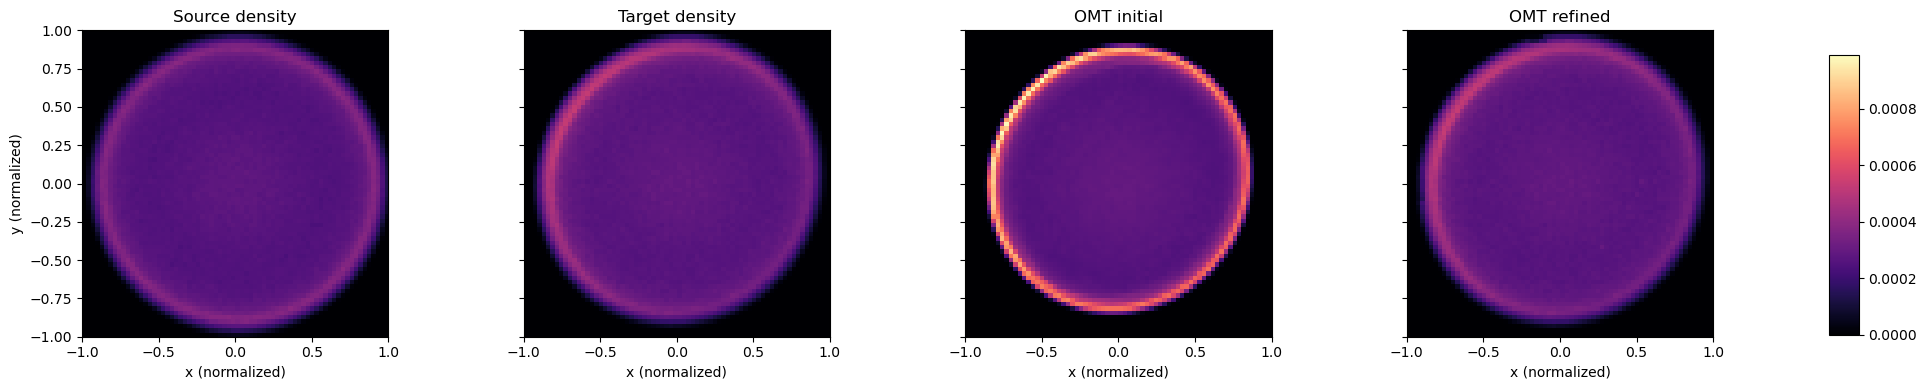

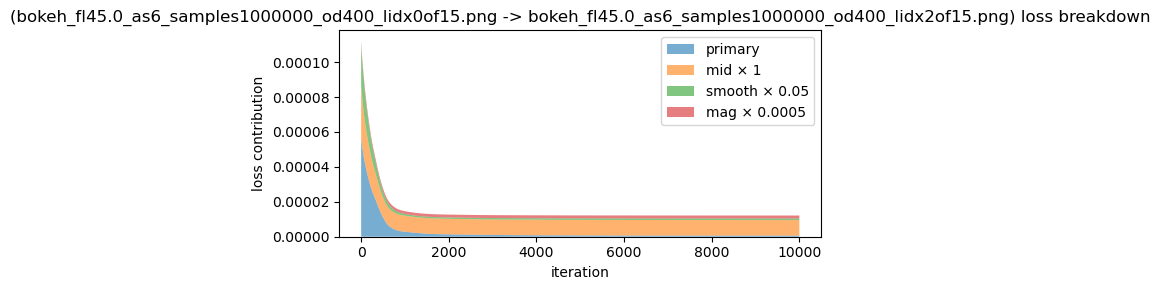

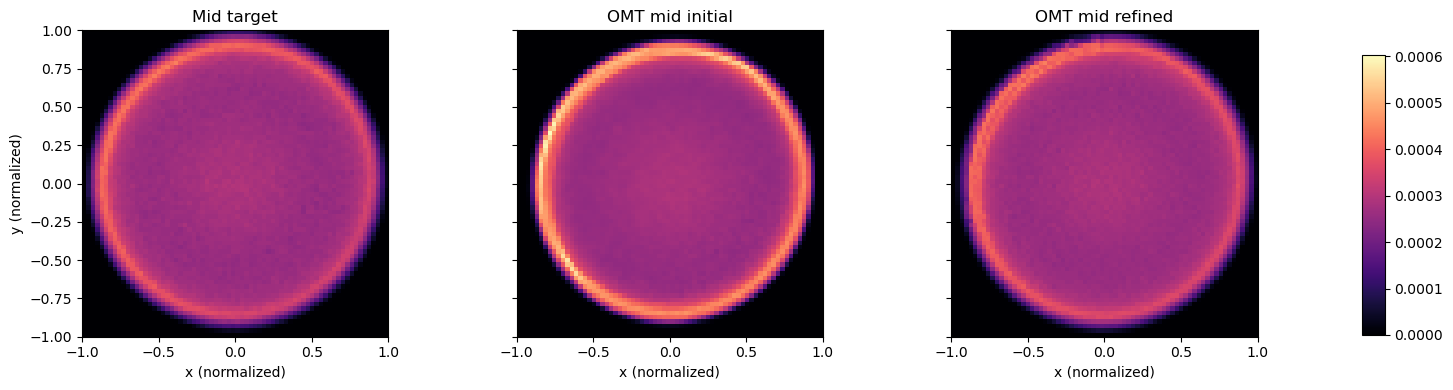

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_00_02.png

=== Distortion map 02_04 ===
Using device: cpu
iter 0001 total 0.000139 (primary 0.000062, mid 0.000028, smooth 0.000929, mag 0.005061)
iter 0500 total 0.000032 (primary 0.000012, mid 0.000008, smooth 0.000216, mag 0.003267)
iter 1000 total 0.000014 (primary 0.000002, mid 0.000008, smooth 0.000051, mag 0.002988)
iter 1500 total 0.000011 (primary 0.000001, mid 0.000007, smooth 0.000026, mag 0.003004)
iter 2000 total 0.000011 (primary 0.000001, mid 0.000008, smooth 0.000023, mag 0.002987)
iter 2500 total 0.000011 (primary 0.000000, mid 0.000008, smooth 0.000023, mag 0.002949)
iter 3000 total 0.000011 (primary 0.000000, mid 0.000008, smooth 0.000023, mag 0.002913)
iter 3500 total 0.000011 (primary 0.000000, mid 0.000008, smooth 0.000023, mag 0.002882)
iter 4000 total 0.000010 (primary 0.000000, mid 0.000008, smooth 0.000023, mag 0.002858)
iter 4500 

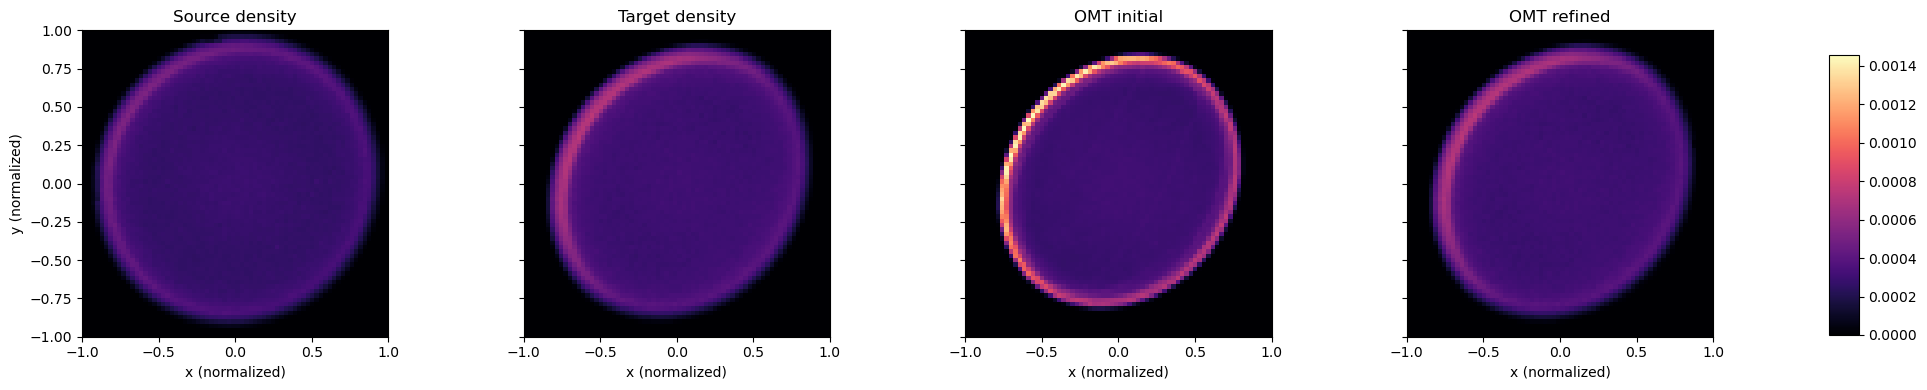

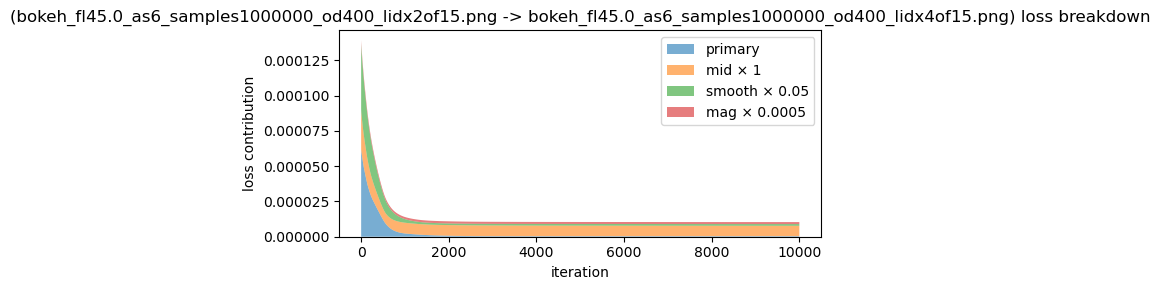

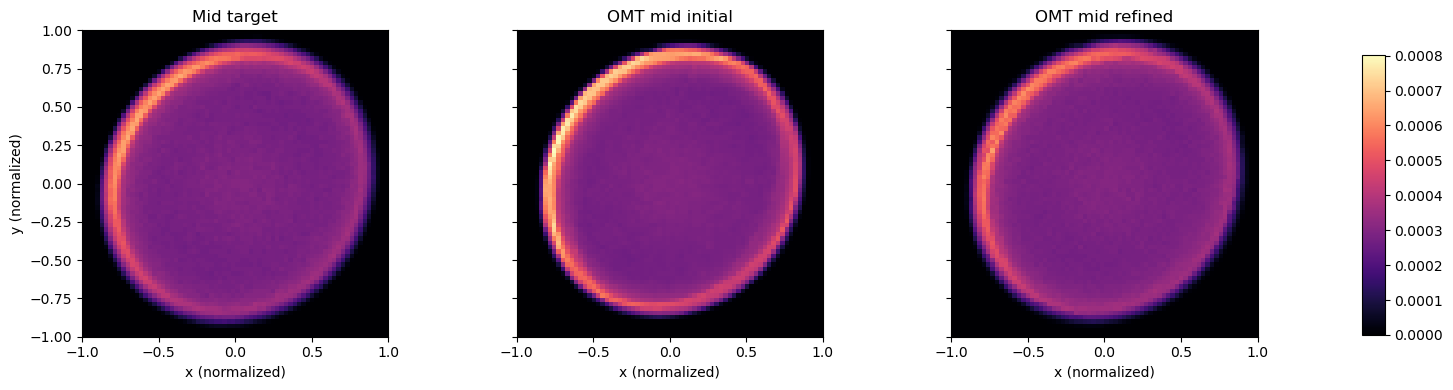

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_02_04.png

=== Distortion map 04_06 ===
Using device: cpu
iter 0001 total 0.000169 (primary 0.000072, mid 0.000031, smooth 0.001242, mag 0.006773)
iter 0500 total 0.000038 (primary 0.000012, mid 0.000006, smooth 0.000352, mag 0.004481)
iter 1000 total 0.000015 (primary 0.000003, mid 0.000006, smooth 0.000090, mag 0.004145)
iter 1500 total 0.000011 (primary 0.000001, mid 0.000006, smooth 0.000034, mag 0.004187)
iter 2000 total 0.000010 (primary 0.000001, mid 0.000006, smooth 0.000024, mag 0.004141)
iter 2500 total 0.000010 (primary 0.000000, mid 0.000006, smooth 0.000022, mag 0.004012)
iter 3000 total 0.000010 (primary 0.000000, mid 0.000006, smooth 0.000022, mag 0.003859)
iter 3500 total 0.000009 (primary 0.000000, mid 0.000006, smooth 0.000022, mag 0.003719)
iter 4000 total 0.000009 (primary 0.000000, mid 0.000006, smooth 0.000022, mag 0.003601)
iter 4500 

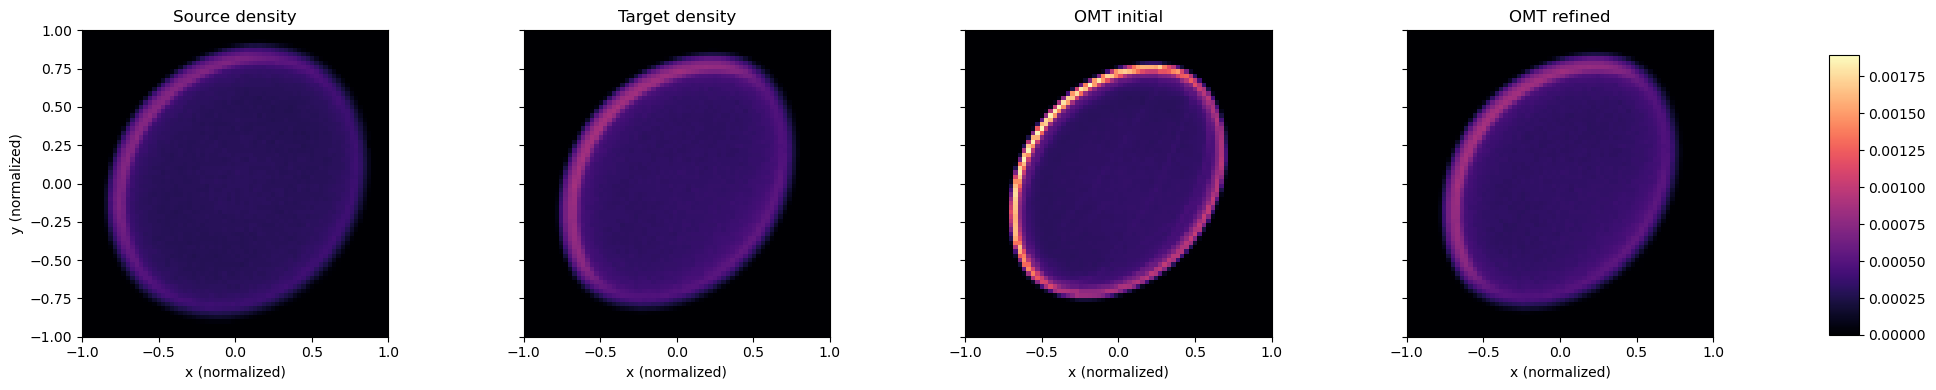

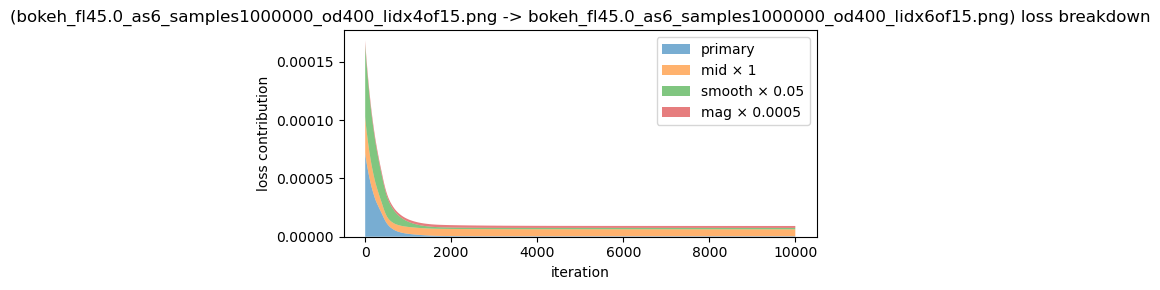

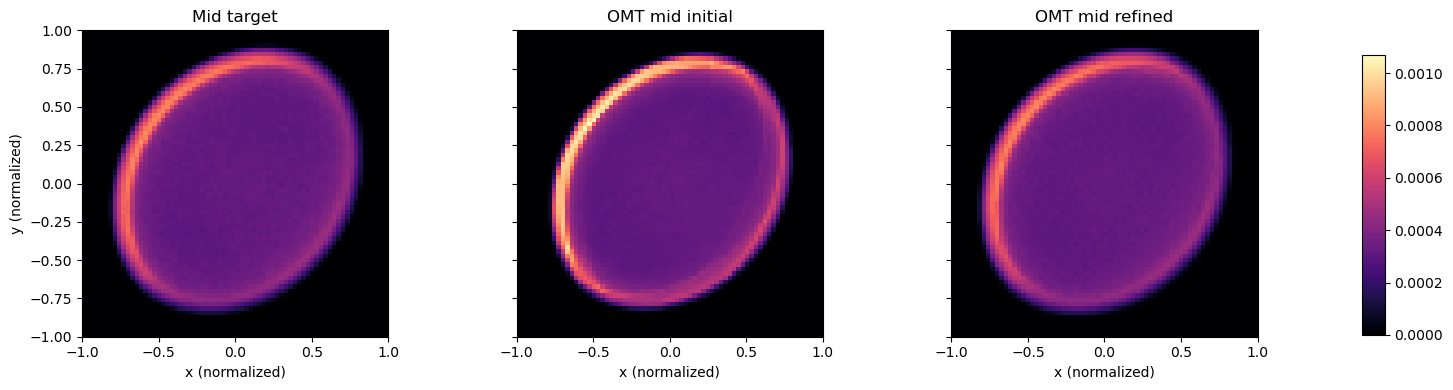

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_04_06.png

=== Distortion map 06_08 ===
Using device: cpu
iter 0001 total 0.000191 (primary 0.000083, mid 0.000035, smooth 0.001381, mag 0.007577)
iter 0500 total 0.000044 (primary 0.000014, mid 0.000006, smooth 0.000432, mag 0.004946)
iter 1000 total 0.000019 (primary 0.000005, mid 0.000006, smooth 0.000123, mag 0.004556)
iter 1500 total 0.000013 (primary 0.000003, mid 0.000006, smooth 0.000047, mag 0.004619)
iter 2000 total 0.000011 (primary 0.000002, mid 0.000006, smooth 0.000032, mag 0.004535)
iter 2500 total 0.000011 (primary 0.000001, mid 0.000006, smooth 0.000029, mag 0.004328)
iter 3000 total 0.000010 (primary 0.000001, mid 0.000006, smooth 0.000027, mag 0.004072)
iter 3500 total 0.000010 (primary 0.000001, mid 0.000006, smooth 0.000026, mag 0.003821)
iter 4000 total 0.000010 (primary 0.000001, mid 0.000006, smooth 0.000026, mag 0.003600)
iter 4500 

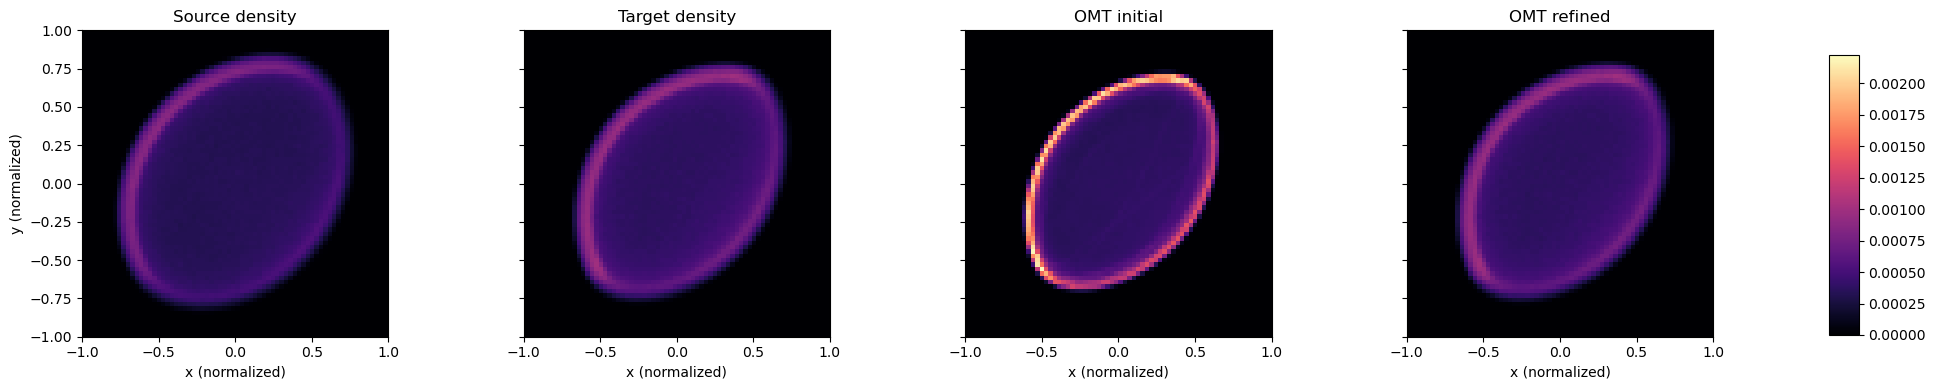

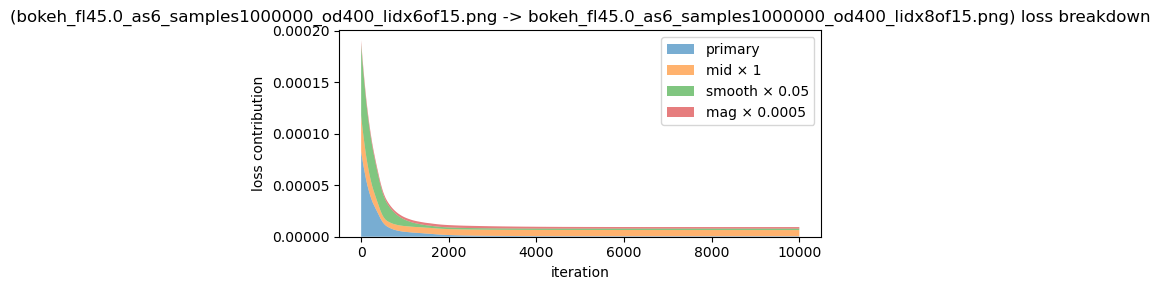

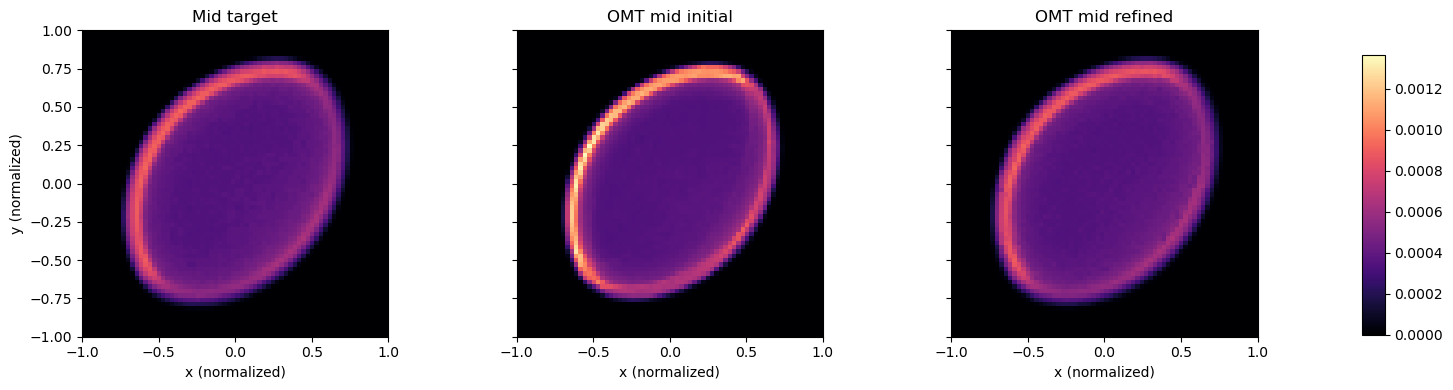

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_06_08.png

=== Distortion map 08_10 ===
Using device: cpu
iter 0001 total 0.000214 (primary 0.000094, mid 0.000040, smooth 0.001524, mag 0.007703)
iter 0500 total 0.000057 (primary 0.000019, mid 0.000010, smooth 0.000508, mag 0.004834)
iter 1000 total 0.000024 (primary 0.000004, mid 0.000010, smooth 0.000157, mag 0.004109)
iter 1500 total 0.000018 (primary 0.000002, mid 0.000011, smooth 0.000060, mag 0.004042)
iter 2000 total 0.000016 (primary 0.000001, mid 0.000011, smooth 0.000038, mag 0.003909)
iter 2500 total 0.000015 (primary 0.000001, mid 0.000011, smooth 0.000032, mag 0.003612)
iter 3000 total 0.000015 (primary 0.000001, mid 0.000011, smooth 0.000028, mag 0.003233)
iter 3500 total 0.000014 (primary 0.000001, mid 0.000011, smooth 0.000025, mag 0.002850)
iter 4000 total 0.000014 (primary 0.000001, mid 0.000011, smooth 0.000023, mag 0.002505)
iter 4500 

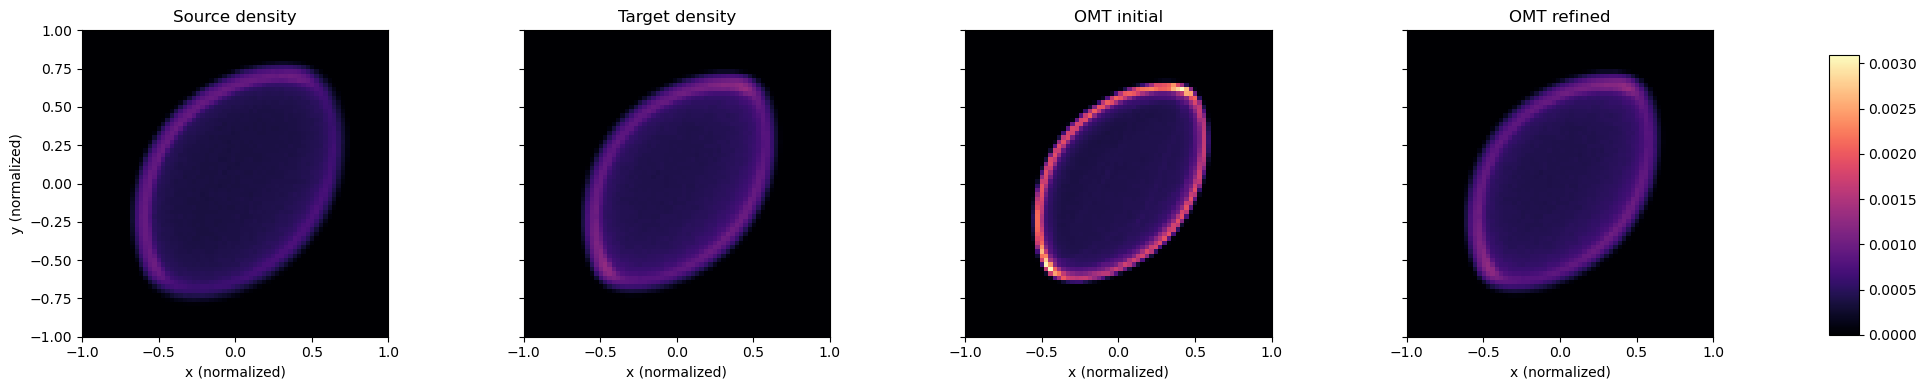

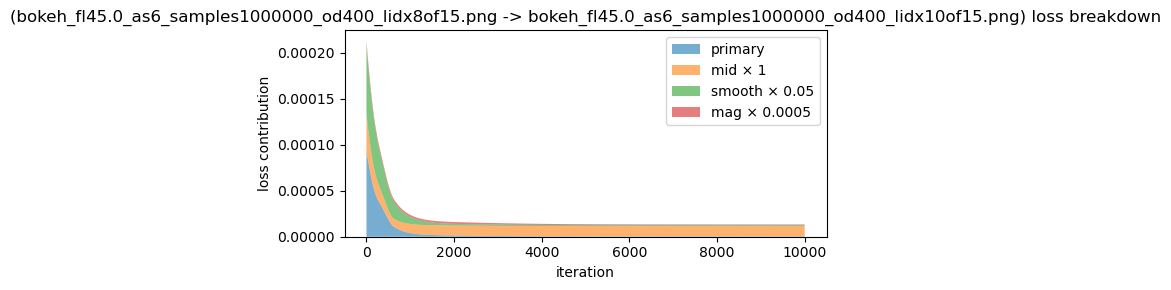

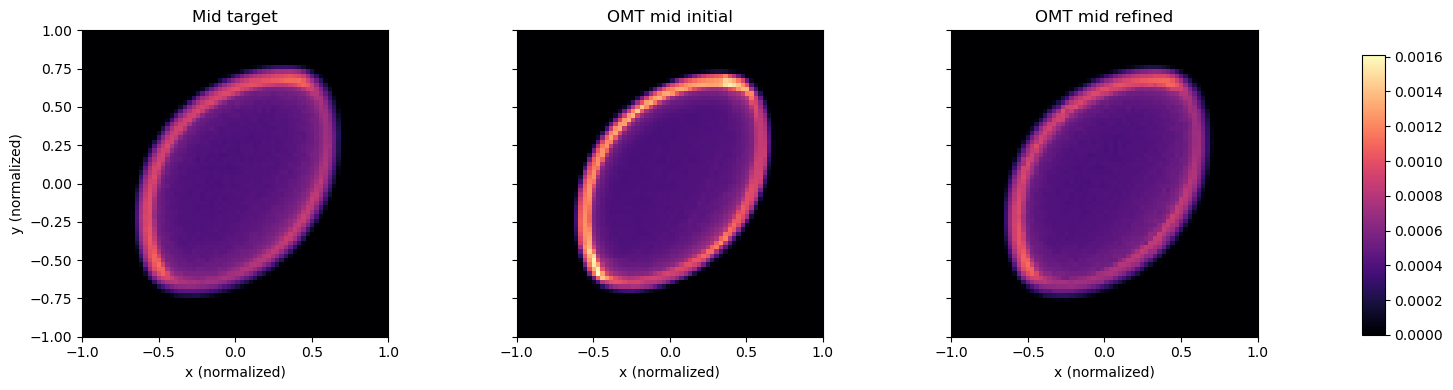

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_08_10.png

=== Distortion map 10_12 ===
Using device: cpu
iter 0001 total 0.000225 (primary 0.000101, mid 0.000042, smooth 0.001555, mag 0.008503)
iter 0500 total 0.000059 (primary 0.000020, mid 0.000009, smooth 0.000555, mag 0.005267)
iter 1000 total 0.000023 (primary 0.000005, mid 0.000006, smooth 0.000187, mag 0.004340)
iter 1500 total 0.000015 (primary 0.000003, mid 0.000007, smooth 0.000076, mag 0.004201)
iter 2000 total 0.000013 (primary 0.000001, mid 0.000007, smooth 0.000048, mag 0.004025)
iter 2500 total 0.000012 (primary 0.000001, mid 0.000007, smooth 0.000039, mag 0.003674)
iter 3000 total 0.000011 (primary 0.000001, mid 0.000007, smooth 0.000034, mag 0.003213)
iter 3500 total 0.000010 (primary 0.000000, mid 0.000007, smooth 0.000029, mag 0.002742)
iter 4000 total 0.000010 (primary 0.000000, mid 0.000007, smooth 0.000026, mag 0.002312)
iter 4500 

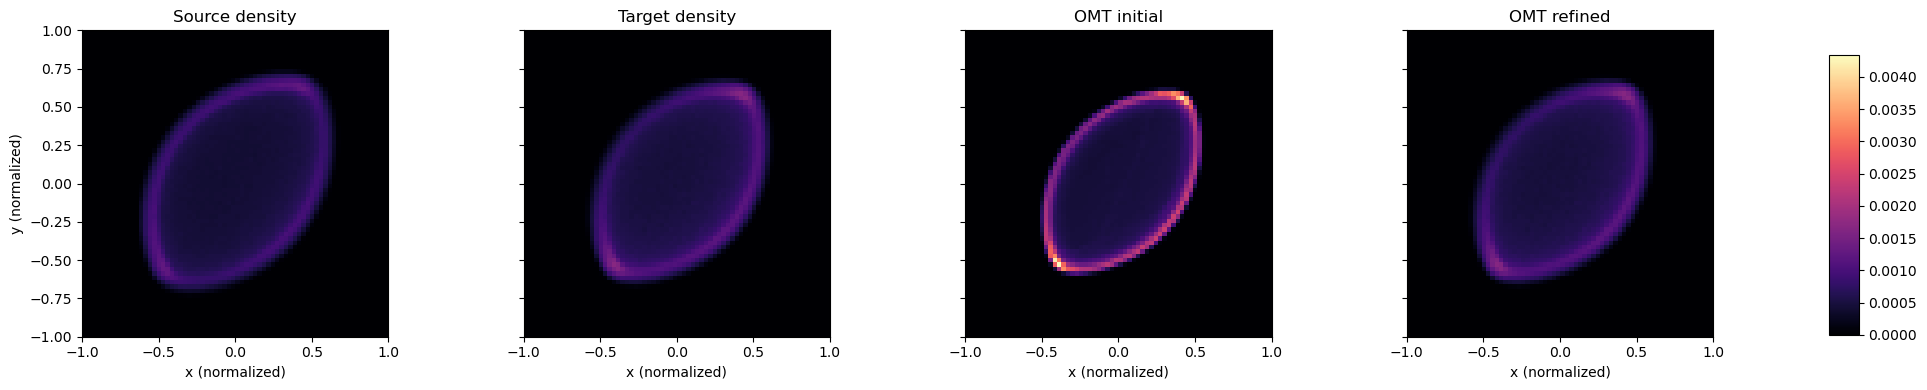

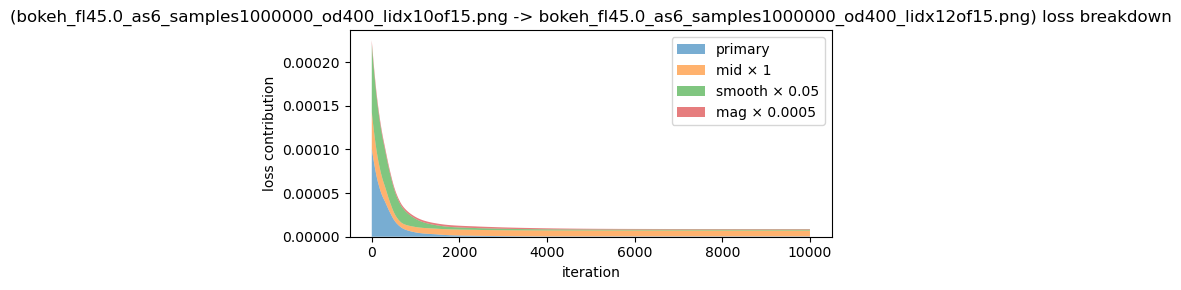

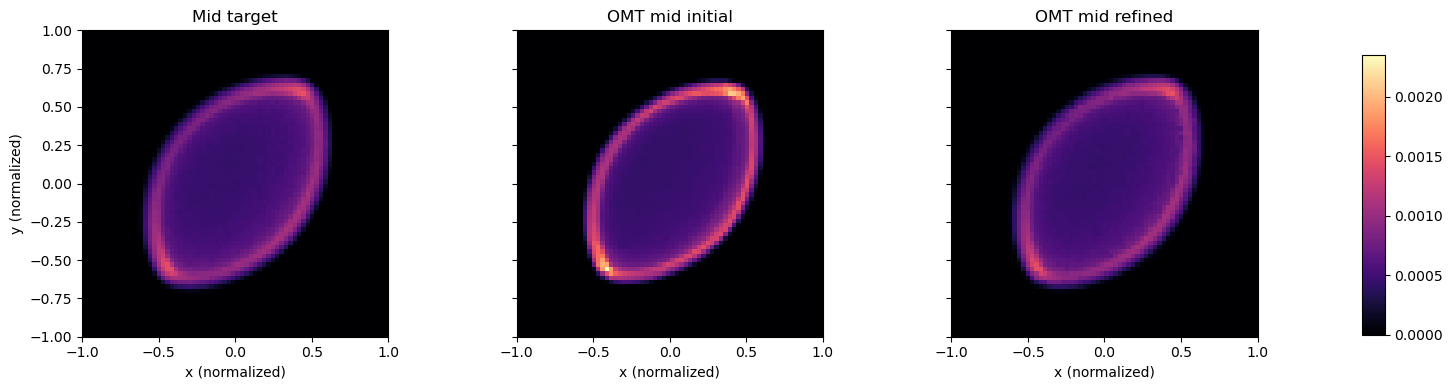

Saved distortion map to C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_10_12.png


In [42]:
output_folder = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/distortion_maps")
desired_resolution = (70, 70)

even_indices = list(range(0, 14, 2))
all_paths = {
    idx: Path(
        f"C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/weights/"
        f"bokeh_fl45.0_as6_samples1000000_od400_lidx{idx}of15.png"
    )
    for idx in range(14)
}
midpoint_paths = {idx: path for idx, path in all_paths.items() if idx % 2 == 1}

refined_source = None
for start_idx, end_idx in zip(even_indices, even_indices[1:]):
    midpoint_idx = start_idx + 1
    midpoint_path = midpoint_paths.get(midpoint_idx)
    label = f"{start_idx:02d}_{end_idx:02d}"
    print(f"\n=== Distortion map {label} ===")
    refined_source = load_images_and_create_distortion_map(
        all_paths[start_idx],
        all_paths[end_idx],
        output_folder / f"distortion_map_{label}.png",
        resolution=desired_resolution,
        source_override=refined_source,
        midpoint_path=midpoint_path,
    )

### Transition noise from one bokeh shape to another

In [43]:
from pathlib import Path

import numpy as np
from PIL import Image

distortion_dir = Path(output_folder)
distortion_maps = sorted(distortion_dir.glob("distortion_map_*.png"))
if not distortion_maps:
    raise FileNotFoundError(f"No distortion maps found in {distortion_dir}")

def load_displacement(path):
    data = np.asarray(Image.open(path), dtype=np.float32)[..., :2]
    dest = (data / 127.5) - 1.0
    dy = dest[..., 1] - source_coords_unit[..., 0]
    dx = dest[..., 0] - source_coords_unit[..., 1]
    return np.stack((dy, dx), axis=-1)

sequence_fields = [load_displacement(path) for path in distortion_maps]
field_height, field_width = sequence_fields[0].shape[:2]

def displacement_at(field, points):
    pts = points.reshape(-1, 2)
    norm = np.clip((pts - value_min) / (value_max - value_min), 0.0, 0.999999)
    y_idx = (norm[:, 0] * (field_height - 1)).astype(int)
    x_idx = (norm[:, 1] * (field_width - 1)).astype(int)
    return field[y_idx, x_idx]

def apply_field(points, field, amount=1.0):
    move = displacement_at(field, points)
    return np.clip(points + amount * move, value_min, value_max)

def move_through_sequence(points, fields, t):
    if not fields:
        return points, 0, 0.0
    total = len(fields)
    progress = np.clip(t, 0.0, 1.0) * total
    segment = min(int(progress), total - 1)
    local = progress - segment
    carried = points.copy()
    for field in fields[:segment]:
        carried = apply_field(carried, field)
    carried = apply_field(carried, fields[segment], amount=local)
    return carried, segment, local

stage_samples = [samples_a]
current = samples_a
for field in sequence_fields:
    current = apply_field(current, field)
    stage_samples.append(current)

segment_titles = [f"Map {i} → {i + 1}" for i in range(len(sequence_fields))]

In [44]:
def render_sequence_frame(t: float):
    interpolated, segment, local_t = move_through_sequence(samples_a, sequence_fields, t)
    start = stage_samples[segment]
    target = stage_samples[min(segment + 1, len(stage_samples) - 1)]
    step = max(1, interpolated.shape[0] // 800)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(start[:, 0], start[:, 1], s=6, alpha=0.35, color="tab:orange", label=f"Start #{segment}")
    ax.scatter(target[:, 0], target[:, 1], s=6, alpha=0.35, color="tab:blue", label=f"Target #{segment + 1}")
    ax.scatter(interpolated[:, 0], interpolated[:, 1], s=8, alpha=0.7, color="tab:green", label="Interpolated")
    delta = interpolated - start
    ax.quiver(start[::step, 0], start[::step, 1], delta[::step, 0], delta[::step, 1], angles="xy", scale_units="xy", scale=1, width=0.0012, color="gray", alpha=0.45)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("dx")
    ax.set_ylabel("dy")
    ax.set_title(f"{segment_titles[segment]} — global t={t:.3f}, local={local_t:.2f}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    return fig

blend_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description="Sequence Blend")

@widgets.interact(t=blend_slider)
def visualize_sequence_interpolation(t: float = 0.0):
    fig = render_sequence_frame(t)
    display(fig)
    plt.close(fig)

interactive(children=(FloatSlider(value=0.0, description='Sequence Blend', max=1.0, step=0.01), Output()), _do…